Campaign Response Rates:
campaign_name
BOGO              0.474211
Flash Sale        0.466106
Holiday Sale      0.497000
New Year Promo    0.479627
Summer Sale       0.482262
Name: responded, dtype: float64

Discount Distribution:
discount
0.25    0.2037
0.15    0.2021
0.10    0.2000
0.20    0.1997
0.30    0.1945
Name: proportion, dtype: float64

Additional Revenue Summary:
count    10000.000000
mean         6.052533
std          8.701082
min          0.000000
25%          0.000000
50%          0.000000
75%         10.310000
max        171.680000
Name: additional_revenue, dtype: float64


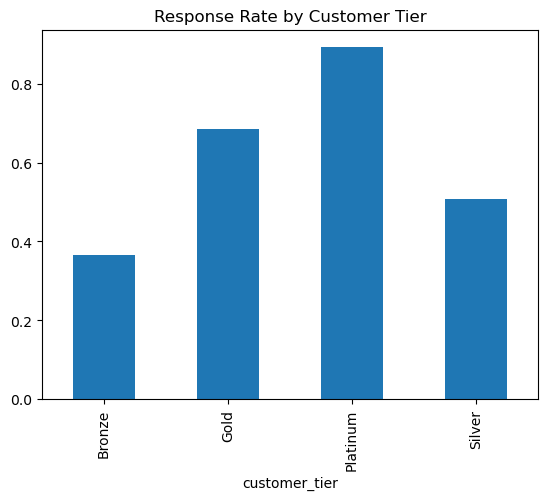

In [1]:
# Step 0: Imports and setup
import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt

# Seeds for reproducibility
Faker.seed(42)
np.random.seed(42)
random.seed(42)
fake = Faker()

# -----------------------------
# Step 1: Recreate Customer Profiles (Step 1 inside Step 4)
# -----------------------------
num_customers = 10000
customer_ids = np.arange(1, num_customers+1)
tiers = ['Bronze','Silver','Gold','Platinum']
tier_probs = [0.5,0.3,0.15,0.05]
customer_tier = np.random.choice(tiers, size=num_customers, p=tier_probs)
countries = ['USA','EU','Asia','Other']
country_probs = [0.4,0.3,0.2,0.1]
customer_country = np.random.choice(countries, size=num_customers, p=country_probs)
names = [fake.name() for _ in range(num_customers)]

customer_profiles = pd.DataFrame({
    'customer_id': customer_ids,
    'name': names,
    'customer_tier': customer_tier,
    'country': customer_country
})

# -----------------------------
# Step 2: Recreate Purchase History (Step 2 inside Step 4)
# -----------------------------
avg_orders_per_customer = 10
order_multiplier = np.random.poisson(lam=avg_orders_per_customer, size=num_customers)
orders_list = []
order_id_counter = 1
for idx, customer_id in enumerate(customer_profiles['customer_id']):
    num_orders = max(1, order_multiplier[idx])
    tier = customer_profiles.loc[idx, 'customer_tier']
    for _ in range(num_orders):
        order_amount = np.random.lognormal(mean=3.5, sigma=0.5)*{'Bronze':1,'Silver':1.5,'Gold':2,'Platinum':3}[tier]
        if np.random.rand()<0.01:  # rare outlier
            order_amount*=10
        orders_list.append({'order_id':order_id_counter,'customer_id':customer_id,'order_amount':round(order_amount,2)})
        order_id_counter+=1

purchase_history = pd.DataFrame(orders_list)

# -----------------------------
# Step 3: Recreate Engagement Behavior (Step 3 inside Step 4)
# -----------------------------
engagement_list = []
for idx, row in customer_profiles.iterrows():
    customer_id = row['customer_id']
    tier = row['customer_tier']
    weekly_visits = np.random.poisson({'Bronze':5,'Silver':8,'Gold':12,'Platinum':20}[tier])
    session_time = np.random.normal(15,5)*(1+tiers.index(tier)*0.1)
    page_views = weekly_visits*np.random.randint(2,5)
    app_opens = max(1,int(weekly_visits*np.random.uniform(0.7,1.3)))
    engagement_list.append({
        'customer_id':customer_id,
        'weekly_visits':weekly_visits,
        'session_time_minutes':round(session_time,2),
        'page_views':page_views,
        'app_opens':app_opens
    })
engagement_behavior = pd.DataFrame(engagement_list)

# -----------------------------
# Step 4: Marketing Promotions Table
# -----------------------------
campaigns = ['Holiday Sale','Flash Sale','BOGO','New Year Promo','Summer Sale']
discounts = [0.10,0.15,0.20,0.25,0.30]  # discount fraction

promotion_list = []

for idx, row in customer_profiles.iterrows():
    customer_id = row['customer_id']
    tier = row['customer_tier']
    
    # Campaign exposure probability (tier-weighted)
    tier_multiplier = {'Bronze':0.5,'Silver':0.7,'Gold':0.9,'Platinum':1.0}
    exposed_campaign = np.random.choice(campaigns, p=[0.2]*5)
    discount = discounts[campaigns.index(exposed_campaign)]
    
    # Response probability: tier + engagement
    engagement_score = engagement_behavior.loc[engagement_behavior['customer_id']==customer_id,'weekly_visits'].values[0]
    base_prob = tier_multiplier[tier]*0.5 + min(engagement_score/50,0.5)
    response = np.random.rand() < base_prob
    
    # ROI placeholder: increase order amount if responded
    avg_order_amount = purchase_history[purchase_history['customer_id']==customer_id]['order_amount'].mean()
    additional_revenue = avg_order_amount*discount*response if not np.isnan(avg_order_amount) else 0
    
    promotion_list.append({
        'customer_id':customer_id,
        'campaign_name':exposed_campaign,
        'discount':discount,
        'responded':response,
        'additional_revenue':round(additional_revenue,2)
    })

marketing_promotions = pd.DataFrame(promotion_list)

# -----------------------------
# Step 5: Validation
# -----------------------------
print("Campaign Response Rates:")
print(marketing_promotions.groupby('campaign_name')['responded'].mean())

print("\nDiscount Distribution:")
print(marketing_promotions['discount'].value_counts(normalize=True))

print("\nAdditional Revenue Summary:")
print(marketing_promotions['additional_revenue'].describe())

# Visual: Response rates per tier
merged = marketing_promotions.merge(customer_profiles[['customer_id','customer_tier']], on='customer_id')
response_by_tier = merged.groupby('customer_tier')['responded'].mean()
response_by_tier.plot(kind='bar', title='Response Rate by Customer Tier')
plt.show()

In [2]:
marketing_promotions.to_csv('../data/marketing_promotions_10k.csv', index=False)
print("marketing_promotions_10k.csv saved!")

marketing_promotions_10k.csv saved!
